# 05 — Survival Analysis (KM, Cox, clinical stratification)


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.config import DATA_PROCESSED, REPORTS_DIR
from src.models.survival_analysis import run_survival_analysis
from src.analysis.stratified_analysis import run_stratified_analysis


,comparison,n_high,n_low,logrank_chi2,logrank_p_value
0,EQD2>=50.0_vs_<50.0,126,64,21.752295,0.000003


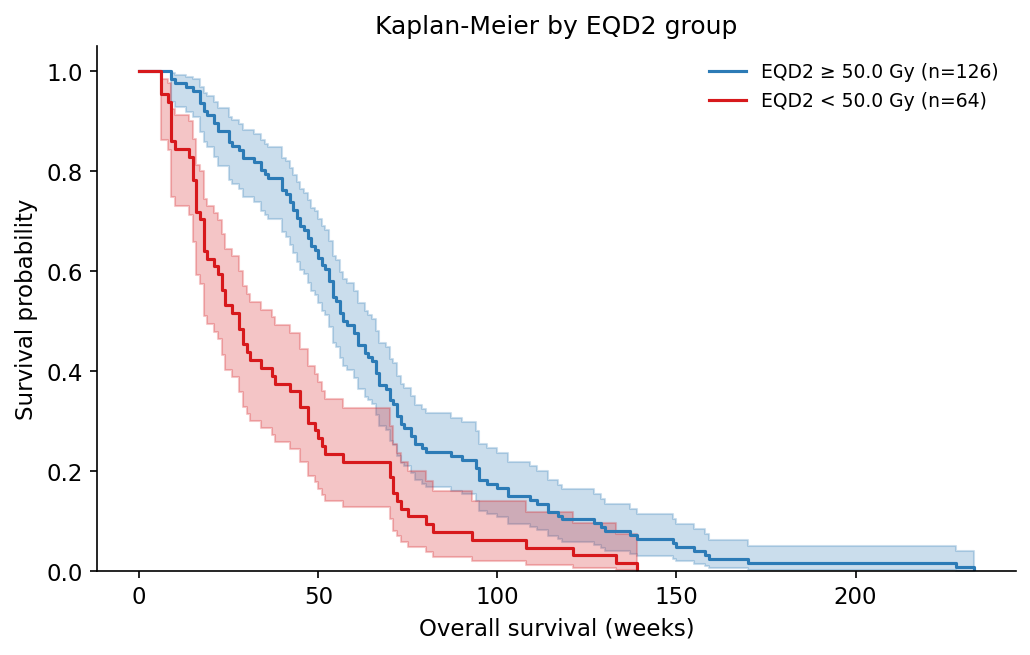

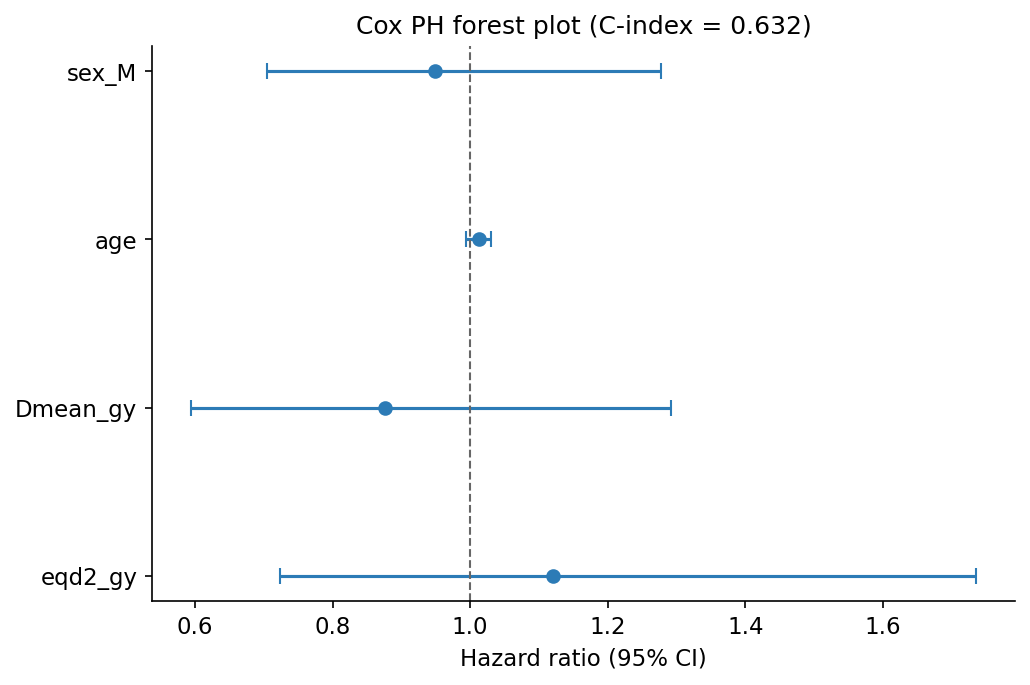

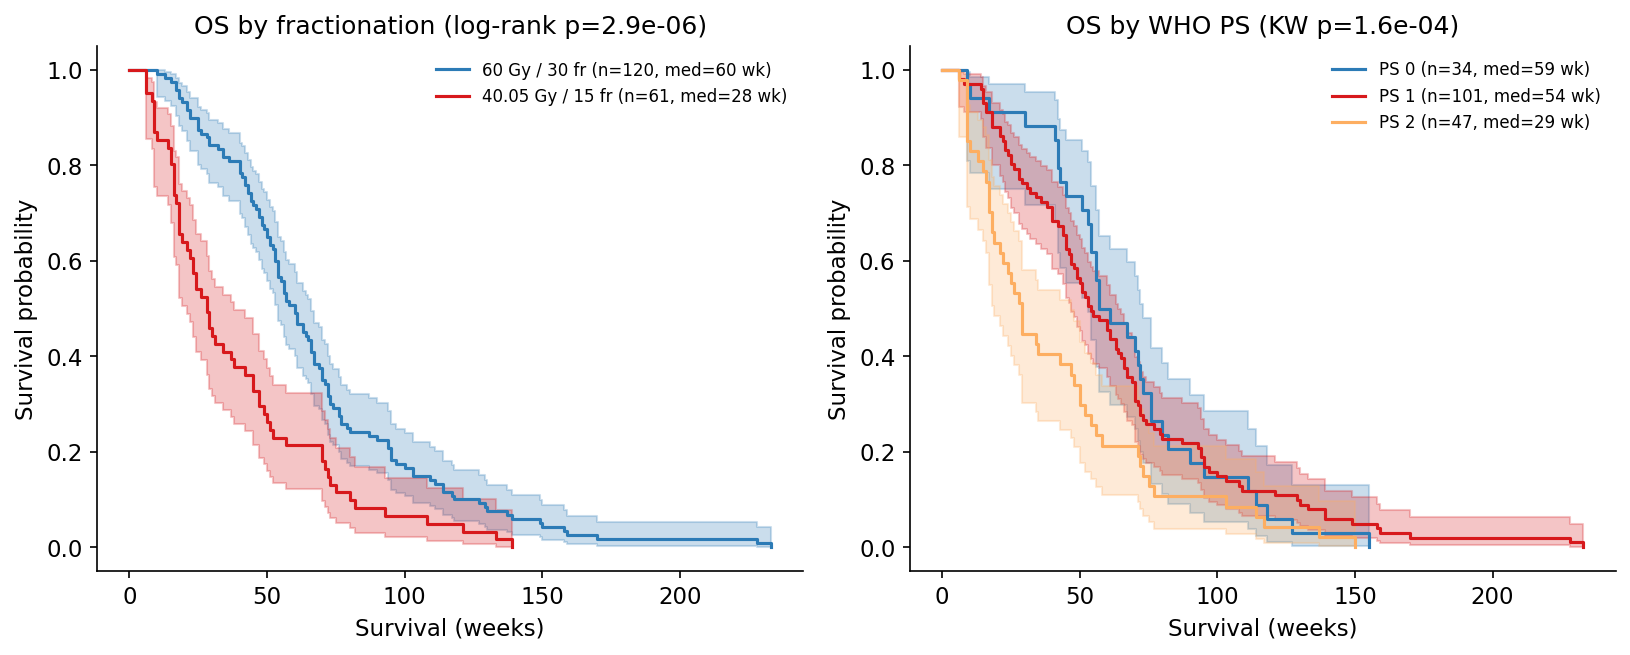

In [2]:
frame = pd.read_csv(DATA_PROCESSED / "modeling_table.csv")
km, cox, _, _ = run_survival_analysis(frame)
clinical, who, within, hypo = run_stratified_analysis(frame, REPORTS_DIR / "metrics")
km


In [3]:
cox[["term", "hazard_ratio", "p"]]


,term,hazard_ratio,p
0,eqd2_gy,1.121049,0.608312
1,Dmean_gy,0.876416,0.505358
2,age,1.012334,0.177563
3,sex_M,0.949154,0.730352


In [4]:
clinical


,term,coef,hazard_ratio,p_value,concordance_index
0,age,0.010677,1.010734,0.234908,0.65603
1,sex_M,0.032850,1.033396,0.829407,0.65603
2,who_status,0.354073,1.424859,0.000948,0.65603
3,scheme_60gy,-0.614101,0.541127,0.000670,0.65603


In [5]:
who


,who_status,n,os_median_wk,os_q25_wk,os_q75_wk
0,0,34,59.0,46.50,79.0
1,1,101,54.0,32.00,77.0
2,2,47,29.0,17.00,55.0
3,3,8,28.0,18.75,39.5
